<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# DOE Fatorial 2³ — (dados da simulação)

## Simulação de Eventos Discretos

### Fatores:

* Lote de compra de **P1** ($15$ / $22$), **P2** ($20$ / $24$),
* **Estoque** (`separados` / `juntos`) ·
* **5 réplicas por tratamento** (8 × 5 = 40 observações)
* KPI: **Lucro**.

### Estrutura do Notebook:

Nesta versão: dados reais fornecidos, cálculo dos efeitos com **intervalo de confiança (IC)**, e uma seção de interpretação dos resultados.

In [1]:
import itertools
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

NAVY, AMBER = "#1A2744", "#E8A020"
plt.rcParams.update({"axes.edgecolor": NAVY, "axes.titleweight": "bold"})

## Dados

In [2]:
dados = pd.DataFrame([
    #  P1   P2      Estoque        R1     R2     R3     R4     R5
    [  15,  20, "separados",      3619,  3651,  3667,  3627,  3665],
    [  15,  20, "juntos",         3469,  3511,  3507,  3452,  3490],
    [  15,  24, "separados",      3739,  3776,  3792,  3782,  3815],
    [  15,  24, "juntos",         3516,  3548,  3579,  3512,  3555],
    [  22,  20, "separados",      3819,  3981,  4147,  4077,  4055],
    [  22,  20, "juntos",         2963,  3084,  3384,  3159,  3215],
    [  22,  24, "separados",      3939,  4106,  4272,  4232,  4205],
    [  22,  24, "juntos",         2963,  3084,  3384,  3159,  3215],
], columns=["P1", "P2", "Estoque", "R1", "R2", "R3", "R4", "R5"])

df = dados.melt(id_vars=["P1", "P2", "Estoque"], value_vars=["R1", "R2", "R3", "R4", "R5"],
                 var_name="replica", value_name="lucro")
dados

,P1,P2,Estoque,R1,R2,R3,R4,R5
0,15,20,separados,3619,3651,3667,3627,3665
1,15,20,juntos,3469,3511,3507,3452,3490
2,15,24,separados,3739,3776,3792,3782,3815
3,15,24,juntos,3516,3548,3579,3512,3555
4,22,20,separados,3819,3981,4147,4077,4055
5,22,20,juntos,2963,3084,3384,3159,3215
6,22,24,separados,3939,4106,4272,4232,4205
7,22,24,juntos,2963,3084,3384,3159,3215


> **Nota sobre os dados:** os tratamentos `(P1=22, P2=20, juntos)` e `(P1=22, P2=24, juntos)` têm exatamente os mesmos 5 valores de lucro. Confirmado: isso é **esperado** — quando P1 está no nível alto e o estoque é `juntos`, o resultado deixa de depender de P2. É um comportamento real do sistema, não um erro de digitação. A seção de **efeitos simples**, logo abaixo da tabela de efeitos, evidencia exatamente esse padrão.

Estoque Juntos = Fator "+" (superior)

Estoque Separados = Fator "-" (superior)

## Cálculo dos efeitos (contrastes)

In [3]:
df_cod = df.copy()
df_cod["A"] = df_cod["P1"].map({15: -1, 22: 1})
df_cod["B"] = df_cod["P2"].map({20: -1, 24: 1})
df_cod["C"] = df_cod["Estoque"].map({"separados": -1, "juntos": 1})

tratamentos = df_cod.groupby(["A", "B", "C"])["lucro"].mean().reset_index()
tratamentos["AB"]  = tratamentos["A"] * tratamentos["B"]
tratamentos["AC"]  = tratamentos["A"] * tratamentos["C"]
tratamentos["BC"]  = tratamentos["B"] * tratamentos["C"]
tratamentos["ABC"] = tratamentos["A"] * tratamentos["B"] * tratamentos["C"]

termos = ["A", "B", "C", "AB", "AC", "BC", "ABC"]
nomes = {"A": "P1", "B": "P2", "C": "Estoque", "AB": "P1×P2",
         "AC": "P1×Estoque", "BC": "P2×Estoque", "ABC": "P1×P2×Estoque"}

efeitos = {t: (tratamentos[t] * tratamentos["lucro"]).sum() / 4 for t in termos}

tabela_efeitos = pd.DataFrame({"Termo": termos,
                                "Fator": [nomes[t] for t in termos],
                                "Efeito": [efeitos[t] for t in termos]})
tabela_efeitos.round(2)

,Termo,Fator,Efeito
0,A,P1,8.55
1,B,P2,81.55
2,C,Estoque,-560.85
3,AB,P1×P2,-14.05
4,AC,P1×Estoque,-361.45
5,BC,P2×Estoque,-53.45
6,ABC,P1×P2×Estoque,-14.05


## Intervalo de confiança (IC) dos efeitos

Cada efeito acima é uma estimativa — precisamos saber sua margem de incerteza. Para um fatorial $2^k$ replicado ($n$ réplicas por tratamento, $N=n\cdot2^k$ observações no total), a variância de qualquer efeito estimado (principal ou interação) é:

$$
\text{Var}(\text{Efeito}) = \frac{4\,\sigma^2}{N} \quad\Rightarrow\quad EP(\text{Efeito}) = 2\sqrt{\frac{\sigma^2}{N}}
$$

$\sigma^2$ é estimada pelo **quadrado médio residual (MSE)** do modelo saturado (todos os efeitos + interações), que aqui equivale exatamente ao **erro puro entre réplicas** ($N - 2^k = 40 - 8 = 32$ graus de liberdade). O IC de $(1-\alpha)$ para cada efeito é:

$$
\text{Efeito} \pm t_{\alpha/2,\;N-2^k}\cdot EP(\text{Efeito})
$$

Um efeito é considerado **significativo** quando esse intervalo **não contém o zero**.

In [4]:
modelo = ols("lucro ~ C(P1) * C(P2) * C(Estoque)", data=df).fit()
anova = sm.stats.anova_lm(modelo, typ=2)

N = len(df)
gl_residual = anova.loc["Residual", "df"]
mse = anova.loc["Residual", "sum_sq"] / gl_residual
ep_efeito = 2 * np.sqrt(mse / N)
t_critico = stats.t.ppf(0.975, gl_residual)   # IC de 95%
margem = t_critico * ep_efeito

tabela_efeitos["EP"] = ep_efeito
tabela_efeitos["IC 95% (inf.)"] = tabela_efeitos["Efeito"] - margem
tabela_efeitos["IC 95% (sup.)"] = tabela_efeitos["Efeito"] + margem
tabela_efeitos["Significativo (IC 95%)"] = np.where(
    (tabela_efeitos["IC 95% (inf.)"] > 0) | (tabela_efeitos["IC 95% (sup.)"] < 0),
    "Sim ✅", "Não ⛔"
)
tabela_efeitos["|Efeito|"] = tabela_efeitos["Efeito"].abs()

tabela_efeitos = tabela_efeitos.sort_values("|Efeito|", ascending=False).reset_index(drop=True)

print(f"MSE (erro puro) = {mse:.1f}  |  gl residual = {int(gl_residual)}  |  "
      f"EP(efeito) = {ep_efeito:.1f}  |  margem (t·EP, 95%) = {margem:.1f}")
tabela_efeitos.round(1)

MSE (erro puro) = 10617.1  |  gl residual = 32  |  EP(efeito) = 32.6  |  margem (t·EP, 95%) = 66.4


,Termo,Fator,Efeito,EP,IC 95% (inf.),IC 95% (sup.),Significativo (IC 95%),|Efeito|
0,C,Estoque,-560.9,32.6,-627.2,-494.5,Sim ✅,560.9
1,AC,P1×Estoque,-361.5,32.6,-427.8,-295.1,Sim ✅,361.5
2,B,P2,81.5,32.6,15.2,147.9,Sim ✅,81.5
3,BC,P2×Estoque,-53.5,32.6,-119.8,12.9,Não ⛔,53.5
4,AB,P1×P2,-14.0,32.6,-80.4,52.3,Não ⛔,14.0
5,ABC,P1×P2×Estoque,-14.0,32.6,-80.4,52.3,Não ⛔,14.0
6,A,P1,8.5,32.6,-57.8,74.9,Não ⛔,8.5


## Efeitos simples de P2 (dentro de cada combinação de P1 × Estoque)

O efeito de P2 calculado acima é uma **média sobre todo o experimento**. Mas o padrão descrito — "quando P1 está alto, P2 deixa de importar" — é um efeito **local**, específico da combinação P1=alto & Estoque=juntos. Para enxergar isso diretamente, calculamos o efeito de P2 (lucro médio no nível alto − lucro médio no nível baixo) **separadamente para cada uma das 4 combinações de P1 × Estoque**:

In [5]:
efeitos_simples = (df.groupby(["P1", "Estoque", "P2"])["lucro"].mean()
                      .unstack("P2")
                      .rename(columns={20: "Lucro médio (P2 baixo)", 24: "Lucro médio (P2 alto)"}))
efeitos_simples["Efeito simples de P2"] = (efeitos_simples["Lucro médio (P2 alto)"]
                                            - efeitos_simples["Lucro médio (P2 baixo)"])
efeitos_simples.round(1)

P2            Lucro médio (P2 baixo)  Lucro médio (P2 alto)  \
P1 Estoque                                                    
15 juntos                     3485.8                 3542.0   
   separados                  3645.8                 3780.8   
22 juntos                     3161.0                 3161.0   
   separados                  4015.8                 4150.8   

P2            Efeito simples de P2  
P1 Estoque                          
15 juntos                     56.2  
   separados                 135.0  
22 juntos                      0.0  
   separados                 135.0

**Leitura:** o efeito de P2 é positivo e de tamanho parecido (≈ +56 a +135) em três das quatro combinações — mas **cai exatamente para zero** quando P1=22 e Estoque=`juntos`.

É essa quebra de padrão, concentrada em **uma única célula do experimento**, que caracteriza uma interação — só que, por afetar apenas 1 de 8 tratamentos, ela é "diluída" quando resumida em um único número de efeito global (por isso a interação tripla, calculada como média geral, apareceu pequena e não significativa mesmo com o padrão sendo real e determinístico nessa célula).

## Pareto dos efeitos (com IC)

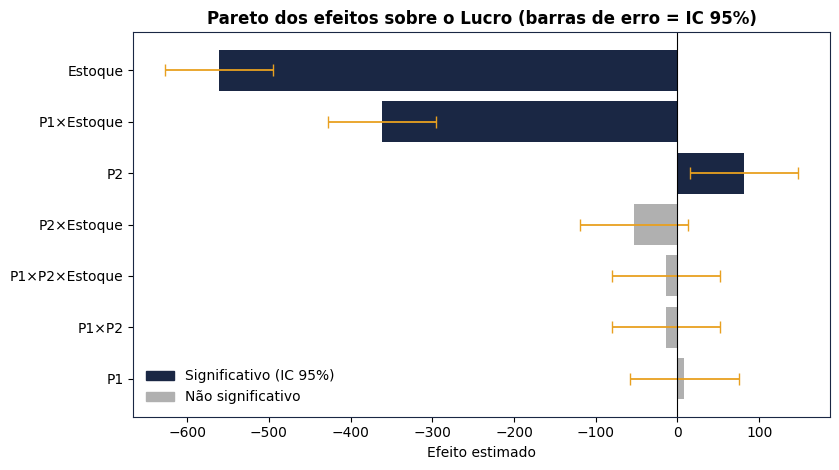

In [6]:
ordem = tabela_efeitos.sort_values("|Efeito|")
cores = [NAVY if s == "Sim ✅" else "#B0B0B0" for s in ordem["Significativo (IC 95%)"]]

plt.figure(figsize=(8.5, 4.8))
plt.barh(ordem["Fator"], ordem["Efeito"], xerr=margem, color=cores,
         capsize=4, error_kw={"elinewidth": 1.3, "ecolor": AMBER})
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pareto dos efeitos sobre o Lucro (barras de erro = IC 95%)")
plt.xlabel("Efeito estimado")

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=NAVY, label="Significativo (IC 95%)"),
                     Patch(color="#B0B0B0", label="Não significativo")],
           frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## ANOVA fatorial (significância)

In [7]:
anova_view = anova.copy().round(4)
anova_view["Conclusão"] = anova_view["PR(>F)"].apply(lambda p: "Significativo ✅" if p < 0.05 else "Não significativo ⛔")
anova_view

,sum_sq,df,F,PR(>F),Conclusão
C(P1),731.025,1.0,0.0689,0.7947,Não significativo ⛔
C(P2),66504.025,1.0,6.2638,0.0176,Significativo ✅
C(Estoque),3145527.225,1.0,296.2692,0.0000,Significativo ✅
C(P1):C(P2),1974.025,1.0,0.1859,0.6692,Não significativo ⛔
C(P1):C(Estoque),1306461.025,1.0,123.0522,0.0000,Significativo ✅
C(P2):C(Estoque),28569.025,1.0,2.6908,0.1107,Não significativo ⛔
C(P1):C(P2):C(Estoque),1974.025,1.0,0.1859,0.6692,Não significativo ⛔
Residual,339748.000,32.0,NaN,NaN,Não significativo ⛔


> Os efeitos apontados como significativos pelo **IC 95%** (tabela de efeitos) e pela **ANOVA** (p < 0,05) coincidem — como deveria ser, já que as duas abordagens usam o mesmo MSE como base.

## Interpretação dos resultados

**Ranking de influência sobre o lucro** (do maior para o menor efeito absoluto):

1. **Estoque** — efeito de aproximadamente **-561**, o maior de todos, e significativo. Passar de estoques `separados` para `juntos` **reduz** o lucro médio em cerca de R$ 561 (mantendo os outros fatores fixos). Aqui, juntar os estoques está **destruindo valor**, não criando.
2. **P1 × Estoque** — segundo maior efeito (≈ -361) e significativo. O efeito do Estoque **não é o mesmo em todos os níveis de P1**: a perda de lucro ao juntar estoques é **mais severa quando P1 está no nível alto (22)**. Combinado com o item 1, a leitura é: *juntar estoques é ruim, e fica pior ainda se P1 for comprado em maior quantidade*.
3. **P2** — efeito positivo (≈ +82) e significativo, mas bem menor que os dois primeiros. Comprar mais de P2 (indo de 20 para 24) aumenta o lucro médio em cerca de R\$ 82 **na média geral do experimento**.
4. **P2 × Estoque** (≈ -53) e **P1** (≈ +9) — não significativos pelo IC 95% nem pela ANOVA quando olhados como médias globais.
5. **P1 × P2** e **P1 × P2 × Estoque** (ambos ≈ -14) — os menores efeitos, também não significativos como médias globais.

**O caso especial:

P2 deixa de importar quando P1 está alto e o estoque é `juntos`.** A tabela de efeitos simples mostra isso de forma direta: o efeito de P2 é de +56 a +135 em três das quatro combinações de P1×Estoque, mas **cai exatamente a zero** na combinação P1=22 & `juntos`.

Isso é consistente com um mecanismo de **saturação/gargalo**: quando o estoque é compartilhado e P1 já está em nível alto, algo (capacidade, orçamento, espaço de armazenagem) provavelmente satura o sistema de tal forma que aumentar P2 não muda mais o resultado.

Note que esse é um padrão **real e localizado em uma única célula do desenho**, por isso o efeito de interação tripla ($P1\times P2\times$Estoque), que é uma **média sobre as 8 combinações**, aparece pequeno (≈ -14) e não significativo — a diluição estatística não significa que o fenômeno seja irrelevante, só que o efeito médio linear não é a melhor forma de capturá-lo.

**Conclusão gerencial:**

- O fator que mais afeta o lucro, isoladamente, **não é a quantidade comprada de P1 ou P2** — é a **decisão de manter os estoques separados**, que está associada aos maiores lucros nesta amostra.
- Como a interação **P1 × Estoque é significativa**, a recomendação não deveria ser genérica ("sempre mantenha separado"), e sim **condicional**: a penalidade de juntar estoques cresce junto com a quantidade comprada de P1.
- O efeito de **P2 isolado é significativo, porém pequeno** frente ao de Estoque — mas isso é uma média: na prática, **o valor de P2 só se realiza quando o estoque está separado ou quando P1 está no nível baixo**. Se a operação for rodar com P1 alto e estoque `juntos`, investir mais em P2 não deve gerar retorno adicional, segundo estes dados.
- **Recomendação combinada:** o melhor cenário observado nos dados é `Estoque = separados` com `P1 = alto` e `P2 = alto` (maior lucro médio entre os 8 tratamentos) — mas se por alguma razão operacional os estoques precisarem ser `juntos`, o dado sugere reduzir P1 para o nível baixo, onde P2 ainda tem efeito positivo sobre o lucro.

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## Referências

- Montgomery, D. C. (2020). *Design and Analysis of Experiments*. 10a ed. Wiley.
- Box, G. E. P., Hunter, J. S., & Hunter, W. G. (2005). *Statistics for Experimenters: Design, Innovation, and Discovery*. 2a ed. Wiley.
- Barros Neto, B., Scarminio, I. S., & Bruns, R. E. (2010). *Como Fazer Experimentos: Pesquisa e Desenvolvimento na Ciência e na Indústria*. 4a ed. Bookman.
- Law, A. M. (2015). *Simulation Modeling and Analysis*. 5a ed. McGraw-Hill.


## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 30-07-2026       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>

<h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>